# Training with GridSearch CV

- The target is then **remaining los** as of the chartdate, instead of **los**
- Try different models - Ridge Regression, LightGBM, XGBoost
- Hyperparameter optimization with early stopping

## 1. Set the training dataframe
- Read the training dataset
- Combine with embeddings of the procedures to use them as features

### Import libraries and set environment

In [45]:
import pandas as pd
import numpy as np
import random
import os
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.base import clone
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import (
    StandardScaler, 
    MinMaxScaler, 
    RobustScaler, 
    OneHotEncoder
)
from sklearn.metrics import (
                            mean_absolute_error, 
                            mean_squared_error,
                            r2_score,
                            roc_auc_score, 
                            roc_curve, 
                            classification_report, 
                            f1_score, 
                            precision_recall_curve, 
                            precision_score, 
                            recall_score)
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn import set_config
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor, early_stopping
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
import matplotlib.pyplot as plt
from wordcloud import WordCloud, STOPWORDS
from adjustText import adjust_text
from collections import Counter

import warnings
warnings.filterwarnings('ignore')

random.seed(5188)
pd.reset_option("display.*")

input_folder = 'Dataset/'
output_folder = 'Merged_Dataset/'
explainability_folder = 'Explainability/'
os.makedirs(os.path.dirname(output_folder), exist_ok=True)
os.makedirs(os.path.dirname(explainability_folder), exist_ok=True)

### Read training data

In [5]:
df_train = pd.read_csv(output_folder+ 'pivot/train_los.csv')

output_filename = "procedures_embeddings.parquet"
output_path = os.path.join(output_folder, output_filename)
df_train

,subject_id,hadm_id,stay_id,chartdate,intime,first_careunit,outtime,remaining los,gender,age,...,Change if_Dialysis,Change if_IABP,Change if_Impella,Change High risk (>51) interventions,Change Low risk (25-50) interventions,procedure_concat,num_procedures,Count of Vasopressor,Latest Vasopressor,is RRT
0,10000690,25860671,37081114,2150-11-03,2150-11-02 19:37:00,Medical Intensive Care Unit (MICU),2150-11-06 17:03:17,3,F,86,...,0.0,0.0,0.0,0.000000,0.0,NaN,0.0,1,1,0
1,10000690,25860671,37081114,2150-11-03,2150-11-02 19:37:00,Medical Intensive Care Unit (MICU),2150-11-06 17:03:17,3,F,86,...,0.0,0.0,0.0,-0.500000,0.0,NaN,0.0,1,1,0
2,10000690,25860671,37081114,2150-11-04,2150-11-02 19:37:00,Medical Intensive Care Unit (MICU),2150-11-06 17:03:17,2,F,86,...,0.0,0.0,0.0,0.333333,0.0,NaN,0.0,1,1,0
3,10000690,25860671,37081114,2150-11-04,2150-11-02 19:37:00,Medical Intensive Care Unit (MICU),2150-11-06 17:03:17,2,F,86,...,0.0,0.0,0.0,-0.500000,0.0,NaN,0.0,1,1,0
4,10000690,25860671,37081114,2150-11-05,2150-11-02 19:37:00,Medical Intensive Care Unit (MICU),2150-11-06 17:03:17,1,F,86,...,0.0,0.0,0.0,0.400000,0.0,NaN,0.0,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
441545,19999442,26785317,32336619,2148-11-26,2148-11-19 14:23:43,Surgical Intensive Care Unit (SICU),2148-11-26 13:12:15,0,M,43,...,0.0,0.0,0.0,-0.307692,0.0,Enteral infusion of concentrated nutritional s...,1.0,0,0,0
441546,19999625,25304202,31070865,2139-10-11,2139-10-10 19:18:00,Medical/Surgical Intensive Care Unit (MICU/SICU),2139-10-11 18:21:28,0,M,82,...,0.0,0.0,0.0,0.000000,0.0,NaN,0.0,0,0,0
441547,19999828,25744818,36075953,2149-01-09,2149-01-08 18:12:00,Medical Intensive Care Unit (MICU),2149-01-10 13:11:02,1,F,48,...,0.0,0.0,0.0,0.000000,0.0,NaN,0.0,0,0,0
441548,19999828,25744818,36075953,2149-01-09,2149-01-08 18:12:00,Medical Intensive Care Unit (MICU),2149-01-10 13:11:02,1,F,48,...,0.0,0.0,0.0,0.000000,0.0,NaN,0.0,0,0,0


In [6]:
df_proc = pd.read_parquet(output_path)
df_proc

,subject_id,hadm_id,stay_id,procedure_concat,procedures_embeddings
0,10000690,25860671,37081114,,"[0.22482169, -0.24363449, -0.03791499, 0.12638..."
1,10001217,24597018,37067082,,"[0.22482169, -0.24363449, -0.03791499, 0.12638..."
2,10001217,27703517,34592300,,"[0.22482169, -0.24363449, -0.03791499, 0.12638..."
3,10001725,25563031,31205490,,"[0.22482169, -0.24363449, -0.03791499, 0.12638..."
4,10002013,23581541,39060235,,"[0.22482169, -0.24363449, -0.03791499, 0.12638..."
...,...,...,...,...,...
96729,19999442,26785317,32336619,,"[0.22482169, -0.24363449, -0.03791499, 0.12638..."
96730,19999442,26785317,32336619,Enteral infusion of concentrated nutritional s...,"[-0.0451852, -0.10551876, -0.13894199, 0.17939..."
96731,19999625,25304202,31070865,,"[0.22482169, -0.24363449, -0.03791499, 0.12638..."
96732,19999828,25744818,36075953,,"[0.22482169, -0.24363449, -0.03791499, 0.12638..."


In [7]:
df_train = pd.merge(df_train,
                    df_proc[['subject_id','hadm_id','stay_id','procedures_embeddings']],
                    on = ['subject_id','hadm_id','stay_id'],
                    how = 'inner')
df_train

,subject_id,hadm_id,stay_id,chartdate,intime,first_careunit,outtime,remaining los,gender,age,...,Change if_IABP,Change if_Impella,Change High risk (>51) interventions,Change Low risk (25-50) interventions,procedure_concat,num_procedures,Count of Vasopressor,Latest Vasopressor,is RRT,procedures_embeddings
0,10000690,25860671,37081114,2150-11-03,2150-11-02 19:37:00,Medical Intensive Care Unit (MICU),2150-11-06 17:03:17,3,F,86,...,0.0,0.0,0.000000,0.0,NaN,0.0,1,1,0,"[0.22482169, -0.24363449, -0.03791499, 0.12638..."
1,10000690,25860671,37081114,2150-11-03,2150-11-02 19:37:00,Medical Intensive Care Unit (MICU),2150-11-06 17:03:17,3,F,86,...,0.0,0.0,-0.500000,0.0,NaN,0.0,1,1,0,"[0.22482169, -0.24363449, -0.03791499, 0.12638..."
2,10000690,25860671,37081114,2150-11-04,2150-11-02 19:37:00,Medical Intensive Care Unit (MICU),2150-11-06 17:03:17,2,F,86,...,0.0,0.0,0.333333,0.0,NaN,0.0,1,1,0,"[0.22482169, -0.24363449, -0.03791499, 0.12638..."
3,10000690,25860671,37081114,2150-11-04,2150-11-02 19:37:00,Medical Intensive Care Unit (MICU),2150-11-06 17:03:17,2,F,86,...,0.0,0.0,-0.500000,0.0,NaN,0.0,1,1,0,"[0.22482169, -0.24363449, -0.03791499, 0.12638..."
4,10000690,25860671,37081114,2150-11-05,2150-11-02 19:37:00,Medical Intensive Care Unit (MICU),2150-11-06 17:03:17,1,F,86,...,0.0,0.0,0.400000,0.0,NaN,0.0,1,1,0,"[0.22482169, -0.24363449, -0.03791499, 0.12638..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1211294,19999828,25744818,36075953,2149-01-09,2149-01-08 18:12:00,Medical Intensive Care Unit (MICU),2149-01-10 13:11:02,1,F,48,...,0.0,0.0,0.000000,0.0,NaN,0.0,0,0,0,"[0.4525915, 0.12640665, 0.100624345, -0.004375..."
1211295,19999828,25744818,36075953,2149-01-09,2149-01-08 18:12:00,Medical Intensive Care Unit (MICU),2149-01-10 13:11:02,1,F,48,...,0.0,0.0,0.000000,0.0,NaN,0.0,0,0,0,"[0.22482169, -0.24363449, -0.03791499, 0.12638..."
1211296,19999828,25744818,36075953,2149-01-09,2149-01-08 18:12:00,Medical Intensive Care Unit (MICU),2149-01-10 13:11:02,1,F,48,...,0.0,0.0,0.000000,0.0,NaN,0.0,0,0,0,"[0.4525915, 0.12640665, 0.100624345, -0.004375..."
1211297,19999828,25744818,36075953,2149-01-10,2149-01-08 18:12:00,Medical Intensive Care Unit (MICU),2149-01-10 13:11:02,0,F,48,...,0.0,0.0,0.000000,0.0,"Insertion of Infusion Device into Upper Vein, ...",1.0,0,0,0,"[0.22482169, -0.24363449, -0.03791499, 0.12638..."


In [8]:
df_train.columns

Index(['subject_id', 'hadm_id', 'stay_id', 'chartdate', 'intime',
       'first_careunit', 'outtime', 'remaining los', 'gender', 'age',
       'anchor_year', 'stay_days', 'anchor_year_group', 'admission_type',
       'admission_location', 'insurance', 'language', 'marital_status', 'race',
       'icu_types', 'assigned_intime', 'assigned_outtime', 'num_chart_events',
       'Respiratory Alarm Margin High', 'Respiratory Alarm Margin Low',
       'Heart rate Alarm Margin High', 'Change in ART BP Mean',
       'Change in Arterial Blood Pressure mean', 'Change in Heart Rate',
       'Change in Heart rate Alarm Margin High',
       'Change in Inspired O2 Fraction',
       'Change in Non Invasive Blood Pressure mean',
       'Change in Resp Alarm - High', 'Change in Resp Alarm - Low',
       'Change in Respiratory Rate', 'Change in Respiratory Alarm Margin High',
       'Change in Respiratory Alarm Margin Low', 'Change in Temperature',
       'Change in Weight', 'Last 24H ART BP Mean',
      

In [9]:
# Check cardinality for categorical features
df_train[['first_careunit', 'gender', 
          'admission_type','insurance', 'language',
          'marital_status']].nunique()

first_careunit    16
gender             2
admission_type     9
insurance          5
language          25
marital_status     4
dtype: int64

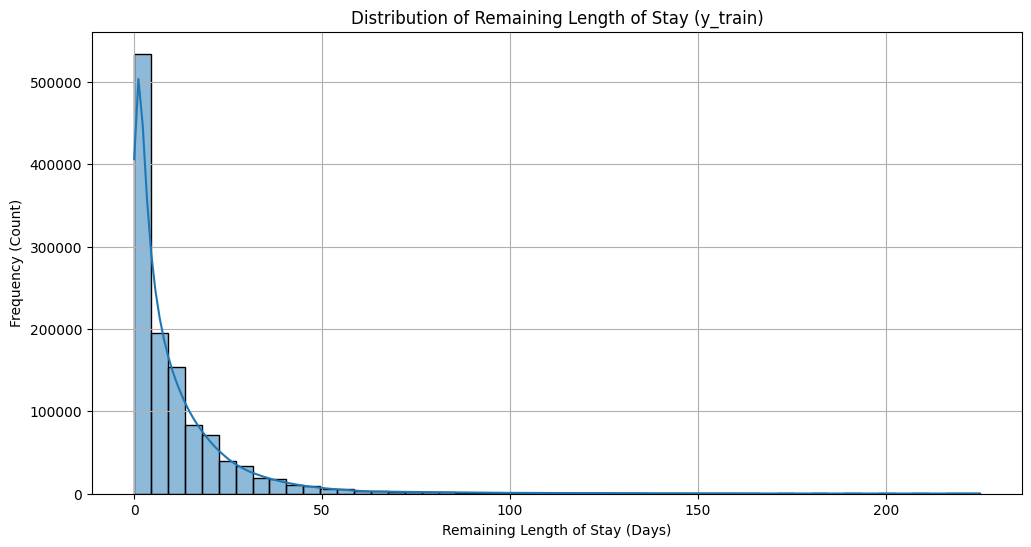

In [10]:
# Check target distribution
plt.figure(figsize=(12, 6))
sns.histplot(df_train['remaining los'], kde=True, bins=50)
plt.title('Distribution of Remaining Length of Stay (y_train)')
plt.xlabel('Remaining Length of Stay (Days)')
plt.ylabel('Frequency (Count)')
plt.grid(True)
plt.show()

In [11]:
# Clip the target to handle outliers. 21 days is a standard for long-stay patients
MIN_STAY_DAYS = 1
MAX_STAY_DAYS = 21

df_train['remaining los'] = df_train['remaining los'].clip(
    lower=MIN_STAY_DAYS, 
    upper=MAX_STAY_DAYS
)

### Correlation matrix of numerical variables

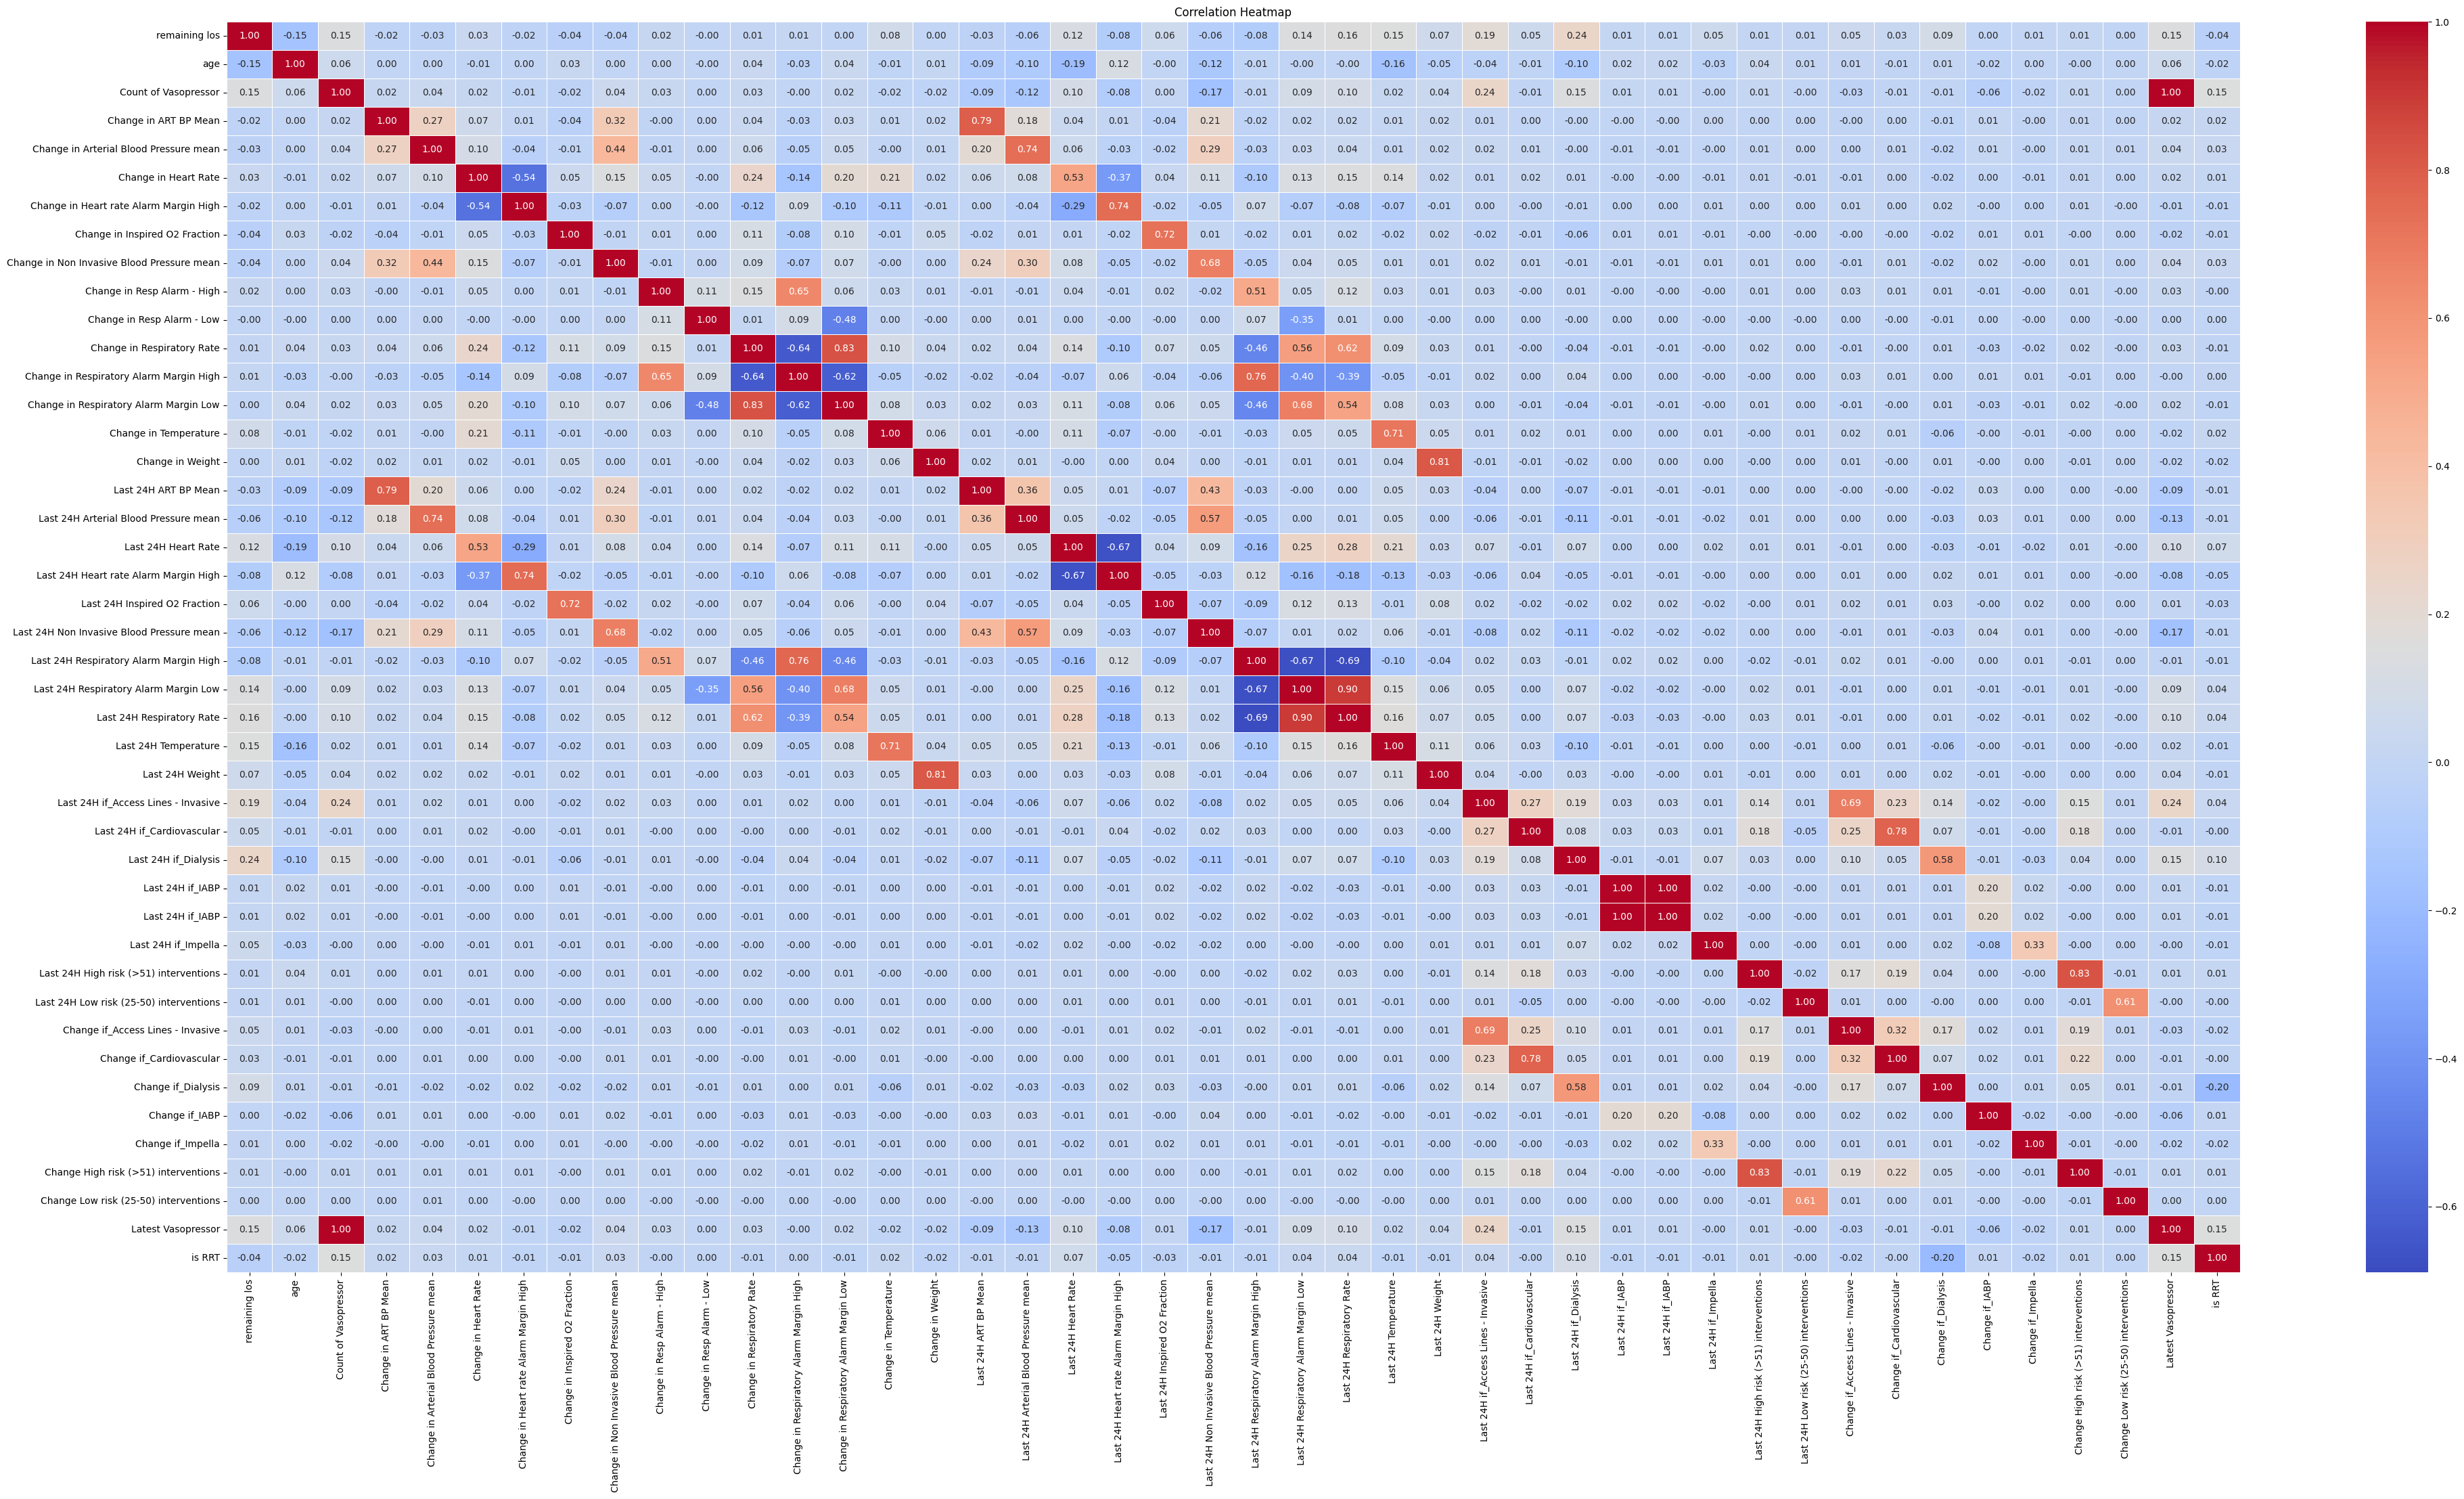

In [12]:
correlation_matrix = df_train[['remaining los','age','Count of Vasopressor',
       'Change in ART BP Mean',
       'Change in Arterial Blood Pressure mean', 'Change in Heart Rate',
       'Change in Heart rate Alarm Margin High',
       'Change in Inspired O2 Fraction',
       'Change in Non Invasive Blood Pressure mean',
       'Change in Resp Alarm - High', 'Change in Resp Alarm - Low',
       'Change in Respiratory Rate', 'Change in Respiratory Alarm Margin High',
       'Change in Respiratory Alarm Margin Low', 'Change in Temperature',
       'Change in Weight', 'Last 24H ART BP Mean',
       'Last 24H Arterial Blood Pressure mean',
       'Last 24H Heart Rate', 'Last 24H Heart rate Alarm Margin High',
       'Last 24H Inspired O2 Fraction',
       'Last 24H Non Invasive Blood Pressure mean',
       'Last 24H Respiratory Alarm Margin High',
       'Last 24H Respiratory Alarm Margin Low', 'Last 24H Respiratory Rate',
       'Last 24H Temperature', 'Last 24H Weight',
       'Last 24H if_Access Lines - Invasive','Last 24H if_Cardiovascular',
       'Last 24H if_Dialysis','Last 24H if_IABP',
       'Last 24H if_IABP', 'Last 24H if_Impella',
       'Last 24H High risk (>51) interventions','Last 24H Low risk (25-50) interventions',                 
       'Change if_Access Lines - Invasive','Change if_Cardiovascular',
       'Change if_Dialysis','Change if_IABP', 'Change if_Impella',
       'Change High risk (>51) interventions','Change Low risk (25-50) interventions',
       'Latest Vasopressor','is RRT']].corr()

# Create the heatmap
plt.figure(figsize=(48, 24))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Heatmap')
plt.show()

#### The matrix shows high correlation between num_chart_events and num_procedures; and between derived vital signs values

## 2. Train the model 
- Since there are 768 (typical BERT) embedding dimensions, we use PCA for dimensionality reduction
- Tried TfIdf but less accuracy (and more features requires), so used embeddings instead
- Set an sklearn pipeline for ease of iterating through multiple hyperparameters and preprocessing steps
- Did not refit the GridSearchCV, so that I can implement early stopping on the final model
- Iterated through multiple combinations of hyperparameters as detailed below

### Time based split

**Perform a time based split to mimic real world data, and to conform to the admission model**

In [13]:
embedding_dim = len(df_train['procedures_embeddings'].iloc[0])
# Test first, and visualize later to select the number of components that will explain 80% of variance
pca = PCA(n_components=min(50, embedding_dim))

# Sort the groups chronologically
df_train = df_train.sort_values(by='assigned_intime')

# Calculate the 80% split point
split_point = int(len(df_train) * 0.8)

# Split the DataFrame into train and test
train_set = df_train.iloc[:split_point]
test_set = df_train.iloc[split_point:]

# Verify the split
print(f"Split percentage: {len(train_set) / len(df_train):.2%}")

Split percentage: 80.00%


### Check that the time ranges do no overlap

In [14]:
train_set[['assigned_intime','intime']]

,assigned_intime,intime
1119918,2008-01-01 01:32:20,2134-01-01 01:32:20
1119917,2008-01-01 01:32:20,2134-01-01 01:32:20
144861,2008-01-01 18:48:11,2132-01-01 18:48:11
144870,2008-01-01 18:48:11,2132-01-01 18:48:11
144868,2008-01-01 18:48:11,2132-01-01 18:48:11
...,...,...
853517,2020-05-17 22:24:28,2200-05-17 22:24:28
853518,2020-05-17 22:24:28,2200-05-17 22:24:28
853519,2020-05-17 22:24:28,2200-05-17 22:24:28
853520,2020-05-17 22:24:28,2200-05-17 22:24:28


In [15]:
test_set[['assigned_intime','intime']]

,assigned_intime,intime
853522,2020-05-17 22:24:28,2200-05-17 22:24:28
853523,2020-05-17 22:24:28,2200-05-17 22:24:28
853524,2020-05-17 22:24:28,2200-05-17 22:24:28
853525,2020-05-17 22:24:28,2200-05-17 22:24:28
853514,2020-05-17 22:24:28,2200-05-17 22:24:28
...,...,...
927074,2025-06-23 05:27:15,2144-06-23 05:27:15
927076,2025-06-23 05:27:15,2144-06-23 05:27:15
927077,2025-06-23 05:27:15,2144-06-23 05:27:15
927073,2025-06-23 05:27:15,2144-06-23 05:27:15


In [16]:
# List of features to use
features = ['first_careunit', 'gender', 'age','Count of Vasopressor',
       'admission_type','insurance','marital_status','Change in ART BP Mean',
       'Change in Arterial Blood Pressure mean', 'Change in Heart Rate',
       'Change in Heart rate Alarm Margin High',
       'Change in Inspired O2 Fraction',
       'Change in Non Invasive Blood Pressure mean',
       'Change in Resp Alarm - High', 'Change in Resp Alarm - Low',
       'Change in Respiratory Rate', 'Change in Respiratory Alarm Margin High',
       'Change in Respiratory Alarm Margin Low', 'Change in Temperature',
       'Change in Weight', 'Last 24H ART BP Mean',
       'Last 24H Arterial Blood Pressure mean',
       'Last 24H Heart Rate', 'Last 24H Heart rate Alarm Margin High',
       'Last 24H Inspired O2 Fraction',
       'Last 24H Non Invasive Blood Pressure mean',
       'Last 24H Respiratory Alarm Margin High',
       'Last 24H Respiratory Alarm Margin Low', 'Last 24H Respiratory Rate',
       'Last 24H Temperature', 'Last 24H Weight',
       'Last 24H if_Access Lines - Invasive','Last 24H if_Cardiovascular',
       'Last 24H if_Dialysis','Last 24H if_IABP', 'Last 24H if_Impella',
       'Last 24H High risk (>51) interventions','Last 24H Low risk (25-50) interventions',                 
       'Change if_Access Lines - Invasive','Change if_Cardiovascular',
       'Change if_Dialysis','Change if_IABP', 'Change if_Impella',
       'Change High risk (>51) interventions','Change Low risk (25-50) interventions',
       'Latest Vasopressor','is RRT']

### Set X_train, y_train, X_test, y_test

In [17]:
set_config(transform_output="pandas")

# X_train and y_train
df_d_embed_train = pd.DataFrame(train_set['procedures_embeddings'].tolist())
df_select_train =  train_set[features].reset_index(drop=True)

df_d_embed_train.columns = [f'proc_emb_{i}' for i in range(embedding_dim)] # Add prefix

X_train = pd.concat([df_d_embed_train,df_select_train], axis=1)
X_train.columns = X_train.columns.astype(str)

# Target variable
y_train = train_set['remaining los'].reset_index(drop=True)
#y_train = np.log1p(y_train)

# X_test and y_test
df_d_embed_test = pd.DataFrame(test_set['procedures_embeddings'].tolist())
df_select_test =  test_set[features].reset_index(drop=True)

df_d_embed_test.columns = [f'proc_emb_{i}' for i in range(embedding_dim)] # Add prefix

X_test = pd.concat([df_d_embed_test,df_select_test], axis=1)
X_test.columns = X_test.columns.astype(str)

# Target variable
y_test = test_set['remaining los'].reset_index(drop=True)

# Get the dimensionality of the embeddings
embedding_dim = len(df_train['procedures_embeddings'].iloc[0])

### Build the sklearn Pipeline for different types of features
Pipeline would be an easy way to permutate different combinations

In [18]:
# Numerical features without outliers. Use MinMax scaling
numeric_features = ['age',
       'Last 24H if_Access Lines - Invasive','Last 24H if_Cardiovascular','Count of Vasopressor',
       'Last 24H if_Dialysis','Last 24H if_IABP', 'Last 24H if_Impella',
       'Last 24H High risk (>51) interventions','Last 24H Low risk (25-50) interventions',
       'Change if_Access Lines - Invasive', 'Change if_Cardiovascular',
       'Change if_Dialysis', 'Change if_IABP', 'Change if_Impella',
       'Change High risk (>51) interventions',
       'Change Low risk (25-50) interventions',
       'Latest Vasopressor','is RRT']
numeric_transformer = Pipeline(
        steps=[("imputer", SimpleImputer(strategy="constant", fill_value=0)), 
               ("scaler", MinMaxScaler())]
    )

# Numerical features with outliers. Use RobustScaler to handle the outliers
numeric_hasoutliers_features = [
       'Change in ART BP Mean',
       'Change in Arterial Blood Pressure mean', 'Change in Heart Rate',
       'Change in Heart rate Alarm Margin High',
       'Change in Inspired O2 Fraction',
       'Change in Non Invasive Blood Pressure mean',
       'Change in Resp Alarm - High', 'Change in Resp Alarm - Low',
       'Change in Respiratory Rate', 'Change in Respiratory Alarm Margin High',
       'Change in Respiratory Alarm Margin Low', 'Change in Temperature',
       'Change in Weight', 'Last 24H ART BP Mean',
       'Last 24H Arterial Blood Pressure mean',
       'Last 24H Heart Rate', 'Last 24H Heart rate Alarm Margin High',
       'Last 24H Inspired O2 Fraction',
       'Last 24H Non Invasive Blood Pressure mean',
       'Last 24H Respiratory Alarm Margin High',
       'Last 24H Respiratory Alarm Margin Low', 'Last 24H Respiratory Rate',
       'Last 24H Temperature', 'Last 24H Weight']
numeric_hasoutliers_transformer = Pipeline(
        steps=[("imputer", SimpleImputer(strategy="constant", fill_value=0)), 
               ("scaler", RobustScaler())]
    )

# Categorical pipeline using OHE
categorical_features = ['first_careunit', 'gender', 
                       'admission_type','insurance',
                       'marital_status']
categorical_transformer = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="constant", fill_value="missing")),
            ("onehot", OneHotEncoder(drop='first', handle_unknown="ignore", sparse_output=False)),
        ]
    )

# Text features. Tried but lesser accuracy than using embeddings
text_transformer = Pipeline(steps=[
     ('tfidf', TfidfVectorizer(max_features=200, dtype=np.float32, stop_words='english'))
])

# Lists for the embedding features based on prefixed names
proc_embedding_features = df_d_embed_train.columns

# PCA
proc_pca_pipeline = Pipeline(steps=[
    ('scaler', StandardScaler()),
    ('pca', pca)
])

# Combine all the preprocessors
preprocessor = ColumnTransformer(
    transformers=[
            ('num', numeric_transformer, numeric_features),
            ('num_hasoutliers', numeric_hasoutliers_transformer, numeric_hasoutliers_features),
            ('cat', categorical_transformer, categorical_features),
#            ('text', text_transformer, 'procedures_concat'),
            ('proc_pca', proc_pca_pipeline, proc_embedding_features),
        ],
    remainder='passthrough'
)

# Grid Search. Get a first pass with default settings to see which algorithms fit better. Random Forest took too long, so just considering Ridge Regression, LightGBM and XGBoost
param_grid = {}

clf_lgbm = Pipeline(
    steps=[("preprocessor", preprocessor),
           ("regressor", LGBMRegressor(
               random_state=42, 
               objective='mae',
               n_jobs=-1
           ))]
)

clf_xgb = Pipeline(
    steps=[("preprocessor", preprocessor),
           ("regressor", XGBRegressor(
               random_state=42, 
               objective='reg:absoluteerror',
               n_jobs=-1
           ))]
)

clf_rf = Pipeline(
    steps=[("preprocessor", preprocessor),
           ("regressor", RandomForestRegressor(
               random_state=42, 
               criterion='absolute_error',
               n_jobs=-1
           ))]
)

clf_lr = Pipeline(
    steps=[("preprocessor", preprocessor),
           ("regressor", Ridge(random_state=42))]
)

grid_search_lr = GridSearchCV(
    clf_lr, 
    param_grid=param_grid, 
    cv=3, 
    scoring='neg_mean_absolute_error', 
    n_jobs=-1, 
    error_score='raise', 
    verbose=2
)

grid_search_lgbm = GridSearchCV(
    clf_lgbm, 
    param_grid=param_grid, 
    cv=3, 
    scoring='neg_mean_absolute_error', 
    n_jobs=-1, 
    error_score='raise', 
    verbose=2
)

grid_search_xgb = GridSearchCV(
    clf_xgb, 
    param_grid=param_grid, 
    cv=3, 
    scoring='neg_mean_absolute_error', 
    n_jobs=-1, 
    error_score='raise', 
    verbose=2
)

grid_search_rf = GridSearchCV(
    clf_rf, 
    param_grid=param_grid, 
    cv=3, 
    scoring='neg_mean_absolute_error', 
    n_jobs=-1, 
    error_score='raise', 
    verbose=2
)

In [19]:
grid_search_lr.fit(X_train, np.ravel(y_train))

Fitting 3 folds for each of 1 candidates, totalling 3 fits


,estimator,Pipeline(step...m_state=42))])
,param_grid,{}
,scoring,'neg_mean_absolute_error'
,n_jobs,-1
,refit,True
,cv,3
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,'raise'
,return_train_score,False
,transformers,"[('num', ...), ('num_hasoutliers', ...), ...]"


In [20]:
grid_search_lgbm.fit(X_train, np.ravel(y_train))

Fitting 3 folds for each of 1 candidates, totalling 3 fits
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.047444 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 20609
[LightGBM] [Info] Number of data points in the train set: 969039, number of used features: 120
[LightGBM] [Info] Start training from score 5.000000


,estimator,Pipeline(step...m_state=42))])
,param_grid,{}
,scoring,'neg_mean_absolute_error'
,n_jobs,-1
,refit,True
,cv,3
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,'raise'
,return_train_score,False
,transformers,"[('num', ...), ('num_hasoutliers', ...), ...]"


In [21]:
grid_search_xgb.fit(X_train, np.ravel(y_train))

Fitting 3 folds for each of 1 candidates, totalling 3 fits


,estimator,"Pipeline(step...=None, ...))])"
,param_grid,{}
,scoring,'neg_mean_absolute_error'
,n_jobs,-1
,refit,True
,cv,3
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,'raise'
,return_train_score,False
,transformers,"[('num', ...), ('num_hasoutliers', ...), ...]"


In [22]:
# Evaluate on unseen test set
print("----Model Evaluation across Linear Regression, LightGBM and XGBoost----")
best_lr = grid_search_lr.best_estimator_
y_pred = best_lr.predict(X_test)
#y_pred = np.expm1(best_lr.predict(X_test))
#y_pred[y_pred < 0] = 0

print(f"Metrics for Ridge Regression: MAE = {mean_absolute_error(y_test, y_pred)}, RMSE = {np.sqrt(mean_squared_error(y_test, y_pred))}")

best_lgbm = grid_search_lgbm.best_estimator_
y_pred = best_lgbm.predict(X_test)
#y_pred = np.expm1(best_lgbm.predict(X_test))
#y_pred[y_pred < 0] = 0

print(f"Metrics for LightGBM: MAE = {mean_absolute_error(y_test, y_pred)}, RMSE = {np.sqrt(mean_squared_error(y_test, y_pred))}")

best_xgb = grid_search_xgb.best_estimator_
y_pred = best_xgb.predict(X_test)
#y_pred = np.expm1(best_xgb.predict(X_test))
#y_pred[y_pred < 0] = 0

print(f"Metrics for XGBoost: MAE = {mean_absolute_error(y_test, y_pred)}, RMSE = {np.sqrt(mean_squared_error(y_test, y_pred))}")

----Model Evaluation across Linear Regression, LightGBM and XGBoost----
Metrics for Ridge Regression: MAE = 5.283642385124174, RMSE = 6.490870426051797
Metrics for LightGBM: MAE = 5.029757905810405, RMSE = 6.688627305704963
Metrics for XGBoost: MAE = 5.207373142242432, RMSE = 6.883347039135949


### PCA to reduce the BERT embeddings. Seems that 50 is good enough to explain 90% of variance

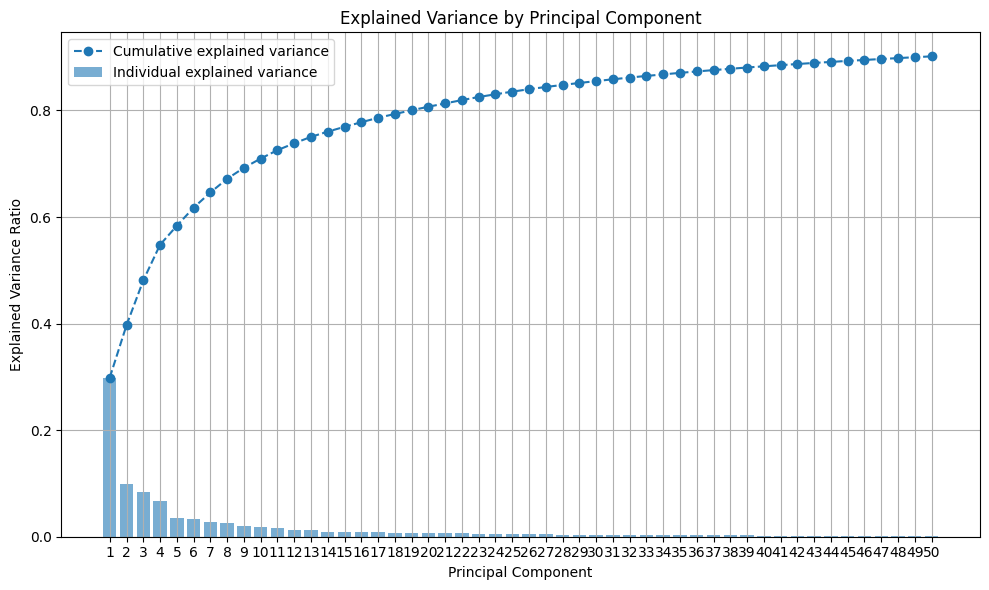

In [23]:
# Fine tune the num of components from PCA
pca_pipeline = best_xgb.named_steps['preprocessor'].named_transformers_['proc_pca']
fitted_pca = pca_pipeline.named_steps['pca']
    
# Get the explained variance ratios
explained_variance = fitted_pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

# Get the number of components for the x-axis
n_components = len(explained_variance)
component_numbers = range(1, n_components + 1)

# Create the plot
plt.figure(figsize=(10, 6))

# Plot individual explained variance
plt.bar(component_numbers, explained_variance, alpha=0.6, align='center',
        label='Individual explained variance')

# Plot cumulative explained variance
plt.plot(component_numbers, cumulative_variance, marker='o', linestyle='--',
         label='Cumulative explained variance')

plt.ylabel('Explained Variance Ratio')
plt.xlabel('Principal Component')
plt.title('Explained Variance by Principal Component')
plt.legend(loc='best')
plt.grid(True)
plt.xticks(component_numbers)
plt.tight_layout()
plt.savefig('pca.png')

### Find optimal n_estimators from early stopping

In [24]:
# Dataset is already sorted so just calculate the 80% split point
split_point = int(len(train_set) * 0.8)

# Split the DataFrame into train and test
train_train_set = train_set.iloc[:split_point]
test_train_set = train_set.iloc[split_point:]

# X_train, y_train
df_d_embed_train_hyp = pd.DataFrame(train_train_set['procedures_embeddings'].tolist())
df_select_train_hyp =  train_train_set[features].reset_index(drop=True)

df_d_embed_train_hyp.columns = [f'proc_emb_{i}' for i in range(embedding_dim)] # Add prefix

X_train_fit = pd.concat([df_d_embed_train_hyp,df_select_train_hyp], axis=1)
X_train_fit.columns = X_train_fit.columns.astype(str)

# Target variable
y_train_fit = train_train_set['remaining los'].reset_index(drop=True)
#y_train = np.log1p(y_train)


# X_test, y_test
df_d_embed_test_hyp = pd.DataFrame(test_train_set['procedures_embeddings'].tolist())
df_select_test_hyp =  test_train_set[features].reset_index(drop=True)

df_d_embed_test_hyp.columns = [f'proc_emb_{i}' for i in range(embedding_dim)] # Add prefix

X_eval = pd.concat([df_d_embed_test_hyp,df_select_test_hyp], axis=1)
X_eval.columns = X_eval.columns.astype(str)

# Target variable
y_eval = test_train_set['remaining los'].reset_index(drop=True)

# Fit with early stopping to the X_train_fit, y_train_fit
preprocessor_for_eval = clone(preprocessor)
preprocessor_for_eval.fit(X_train_fit, y_train_fit)
X_eval_transformed = preprocessor_for_eval.transform(X_eval)

### Hyperparameter Tuning

In [25]:
set_config(transform_output="pandas")
# Try on a few common values in the grid for LightGBM
# Use n_estimators = 1000 for early stopping
param_grid = {
     'regressor__n_estimators': [1000],
     'regressor__learning_rate': [0.001, 0.05, 0.1],
     'regressor__num_leaves': [31, 63],
     'regressor__reg_lambda': [1, 3],
 }

fit_params = {
    'regressor__eval_set': [(X_eval_transformed, np.ravel(y_eval))],
    'regressor__callbacks': [early_stopping(50, verbose=False)]
}

clf = Pipeline(
    steps=[("preprocessor", preprocessor),
           ("regressor", LGBMRegressor(random_state=42,
                                     objective='regression_l1',
                                     n_jobs=-1,
                                     verbose=-1))]
)

# Using this to find the best params, not to build the final model
grid_search = GridSearchCV(
    clf, 
    param_grid=param_grid, 
    cv=2,
    scoring='neg_mean_absolute_error', 
    n_jobs=-1, 
    error_score='raise', 
    verbose=2,
    refit=False
)

grid_search.fit(X_train_fit, np.ravel(y_train_fit))

print("Best Parameters:", grid_search.best_params_)
print("Refitting best model with early stopping to get n_estimators")

# Create a new pipeline
final_model = clone(clf)

# Set the best params found by the grid search
final_model.set_params(**grid_search.best_params_)

# Fit the final model
final_model.fit(X_train_fit, np.ravel(y_train_fit), **fit_params)
best_rf = final_model 
print(f"Best number of estimators: {best_rf.named_steps['regressor'].n_estimators}")
print(f"Actual best iteration found by stopping: {best_rf.named_steps['regressor'].best_iteration_}")

Fitting 2 folds for each of 12 candidates, totalling 24 fits
[CV] END regressor__learning_rate=0.05, regressor__n_estimators=1000, regressor__num_leaves=31, regressor__reg_lambda=1; total time= 2.6min
[CV] END regressor__learning_rate=0.1, regressor__n_estimators=1000, regressor__num_leaves=31, regressor__reg_lambda=3; total time= 2.4min
[CV] END regressor__learning_rate=0.001, regressor__n_estimators=1000, regressor__num_leaves=31, regressor__reg_lambda=3; total time= 2.8min
[CV] END regressor__learning_rate=0.1, regressor__n_estimators=1000, regressor__num_leaves=63, regressor__reg_lambda=3; total time= 2.5min
Best Parameters: {'regressor__learning_rate': 0.05, 'regressor__n_estimators': 1000, 'regressor__num_leaves': 31, 'regressor__reg_lambda': 1}
Refitting best model with early stopping to get n_estimators
Best number of estimators: 1000
Actual best iteration found by stopping: 732


### Once the best hyperparameters are obtained from the GridSearch, fit fully on the original X_train with 5-fold CV

In [26]:
# Use the best params from hyperparameter tuning
param_grid = {
     'regressor__n_estimators': [651],
     'regressor__learning_rate': [0.05],
     'regressor__num_leaves': [31],
     'regressor__reg_lambda': [3],

}

clf = Pipeline(
    steps=[("preprocessor", preprocessor),
           ("regressor", LGBMRegressor(random_state=42,
                                     objective='regression_l1',
                                     n_jobs=-1,
                                     verbose=-1))]
)

grid_search = GridSearchCV(
    clf, 
    param_grid=param_grid, 
    cv=5,
    scoring='neg_mean_absolute_error', 
    n_jobs=-1, 
    error_score='raise', 
    verbose=2,
    refit=True
)

# Fit on the original training dataset
grid_search.fit(X_train, np.ravel(y_train))

Fitting 5 folds for each of 1 candidates, totalling 5 fits
[CV] END regressor__learning_rate=0.001, regressor__n_estimators=1000, regressor__num_leaves=31, regressor__reg_lambda=1; total time= 2.8min
[CV] END regressor__learning_rate=0.1, regressor__n_estimators=1000, regressor__num_leaves=63, regressor__reg_lambda=1; total time= 2.5min
[CV] END regressor__learning_rate=0.05, regressor__n_estimators=651, regressor__num_leaves=31, regressor__reg_lambda=3; total time=  42.8s
[CV] END regressor__learning_rate=0.001, regressor__n_estimators=1000, regressor__num_leaves=63, regressor__reg_lambda=3; total time= 5.3min
[CV] END regressor__learning_rate=0.05, regressor__n_estimators=651, regressor__num_leaves=31, regressor__reg_lambda=3; total time=  49.2s
[CV] END regressor__learning_rate=0.001, regressor__n_estimators=1000, regressor__num_leaves=31, regressor__reg_lambda=3; total time= 4.4min
[CV] END regressor__learning_rate=0.05, regressor__n_estimators=651, regressor__num_leaves=31, regres

,estimator,Pipeline(step...verbose=-1))])
,param_grid,"{'regressor__learning_rate': [0.05], 'regressor__n_estimators': [651], 'regressor__num_leaves': [31], 'regressor__reg_lambda': [3]}"
,scoring,'neg_mean_absolute_error'
,n_jobs,-1
,refit,True
,cv,5
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,'raise'
,return_train_score,False
,transformers,"[('num', ...), ('num_hasoutliers', ...), ...]"


### Final Accuracy Metrics after hyperparameter optimization

#### Predict the test set

In [27]:
# Evaluate on unseen test set
#y_pred = np.expm1(best_rf.predict(X_test))
#y_pred[y_pred < 0] = 0
y_pred = grid_search.best_estimator_.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"Test Set MAE for XGBoost after hyperparameter optimization: {mae}")
print(f"Test Set RMSE for XGBoost after hyperparameter optimization: {rmse}")

Test Set MAE for XGBoost after hyperparameter optimization: 5.058726529545978
Test Set RMSE for XGBoost after hyperparameter optimization: 6.701288181254245


### Look at MAE across each bin to compare long stays vs shorter stays

In [28]:
results_df = pd.DataFrame({
    'actual_remaining_los': y_test,
    'predicted_remaining_los': y_pred
})

results_df['abs_error'] = (results_df['actual_remaining_los'] - results_df['predicted_remaining_los']).abs()

# Define the bins for stratification
bins = [0, 2, 5, 10, 20, np.inf]
labels = ['0-2 days', '2-5 days', '5-10 days', '10-20 days', '20+ days']

# Bin the data based on the remaining LoS
results_df['los_bin'] = pd.cut(
    results_df['actual_remaining_los'], 
    bins=bins, 
    labels=labels, 
    right=False
)

# Calculate the MAE for each bin
stratified_mae = results_df.groupby('los_bin')['abs_error'].mean()
bin_counts = results_df['los_bin'].value_counts().sort_index()

print("--- Stratified MAE Analysis ---")
print("Mean Absolute Error (MAE) by actual remaining LoS:")
print(stratified_mae)

print("Number of predictions in each bin:")
print(bin_counts)

--- Stratified MAE Analysis ---
Mean Absolute Error (MAE) by actual remaining LoS:
los_bin
0-2 days      2.670582
2-5 days      3.430649
5-10 days     3.606646
10-20 days    5.262861
20+ days      8.600417
Name: abs_error, dtype: float64
Number of predictions in each bin:
los_bin
0-2 days      45495
2-5 days      43556
5-10 days     42106
10-20 days    45779
20+ days      65324
Name: count, dtype: int64


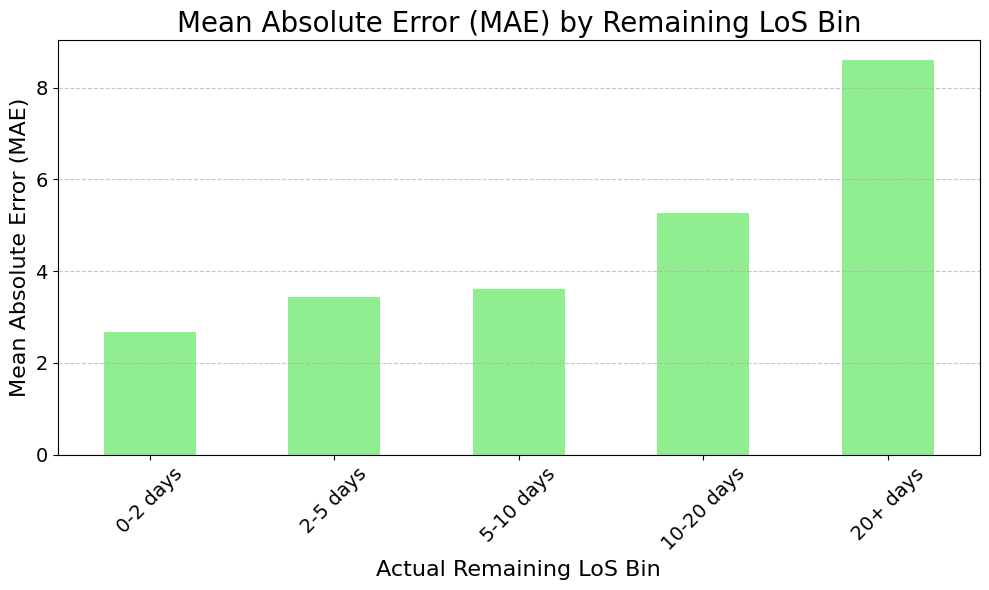

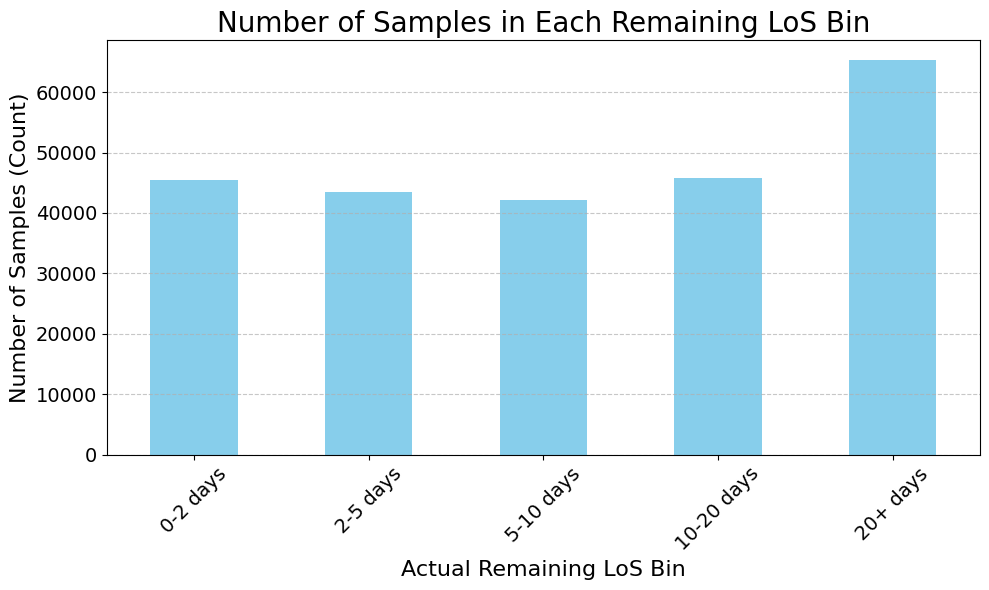

In [29]:
# Plot 1: Stratified MAE
plt.figure(figsize=(10, 6))
stratified_mae.sort_index().plot(kind='bar', color='lightgreen')

plt.title('Mean Absolute Error (MAE) by Remaining LoS Bin', fontsize=20)
plt.xlabel('Actual Remaining LoS Bin', fontsize=16)
plt.ylabel('Mean Absolute Error (MAE)', fontsize=16)
plt.xticks(rotation=45, fontsize=14)
plt.yticks(fontsize=14)

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('stratified_mae_plot.png')

# Plot 2: Bin Counts (Data Distribution)
plt.figure(figsize=(10, 6))
bin_counts.plot(kind='bar', color='skyblue')

plt.title('Number of Samples in Each Remaining LoS Bin', fontsize=20)
plt.xlabel('Actual Remaining LoS Bin', fontsize=16)
plt.ylabel('Number of Samples (Count)', fontsize=16)
plt.xticks(rotation=45, fontsize=14)
plt.yticks(fontsize=14)

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('bin_counts_plot.png')

## 3. Training Information

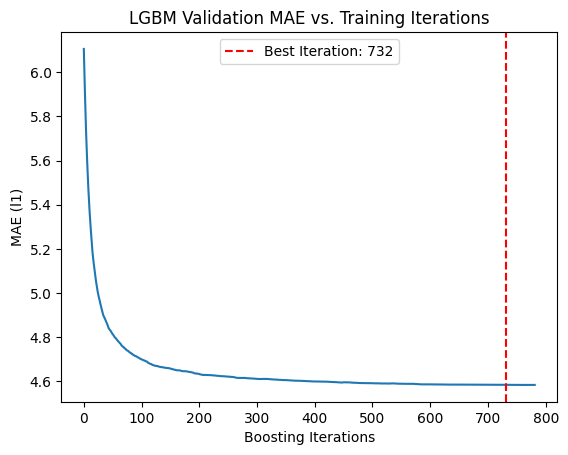

In [30]:
# Get the results from the regressor steps inside final model
hist = final_model.named_steps['regressor'].evals_result_

plt.plot(hist['valid_0']['l1'])

# Get the best iteration from that same regressor step
best_iter = final_model.named_steps['regressor'].best_iteration_

# Plot the vertical line
plt.axvline(best_iter, color='r', linestyle='--', label=f'Best Iteration: {best_iter}')

plt.xlabel("Boosting Iterations")
plt.ylabel("MAE (l1)")
plt.title("LGBM Validation MAE vs. Training Iterations")
plt.legend()
plt.savefig("training.png")

## 4. Feature Importance and Explainability

### Feature Importance

In [46]:
best_pipeline = grid_search.best_estimator_

feature_importances = best_pipeline.named_steps['regressor'].feature_importances_

# Get column names after preprocessing
preprocessed_columns = best_pipeline.named_steps['preprocessor'].get_feature_names_out()

# Combine feature names with their importance
feature_importance_df = pd.DataFrame({
    'Feature': preprocessed_columns,
    'Importance': feature_importances
}).sort_values(by='Importance', ascending=False)

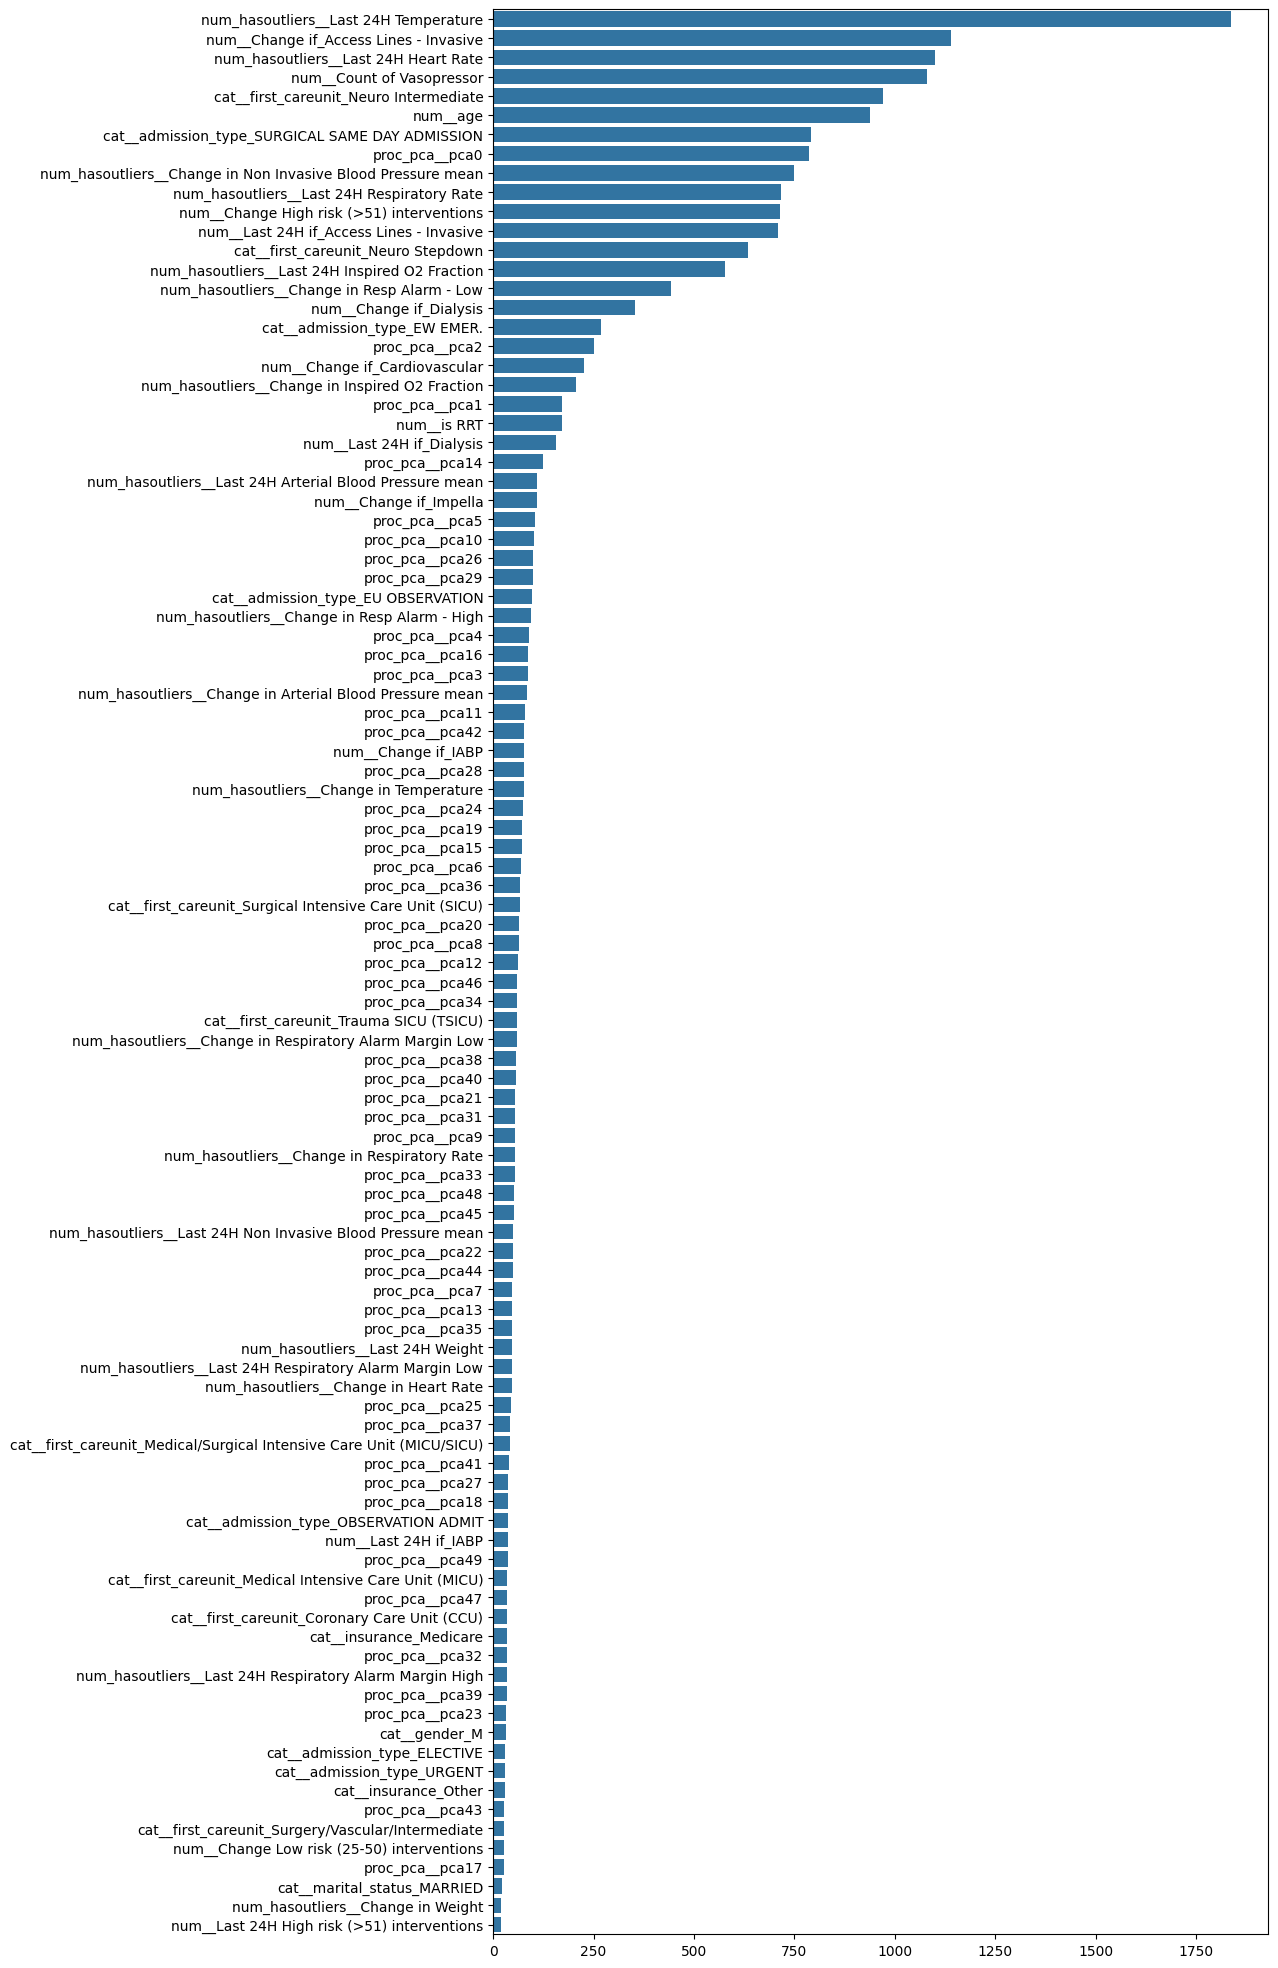

In [47]:
fig, ax = plt.subplots(figsize=(10, 25))
ax = sns.barplot(data=feature_importance_df.iloc[:100] , x='Importance', y='Feature',color='tab:blue').set(xlabel=None,ylabel=None)

In [48]:
fig.tight_layout()
fig.savefig(explainability_folder +"ft.png", dpi=300)

### SHAP

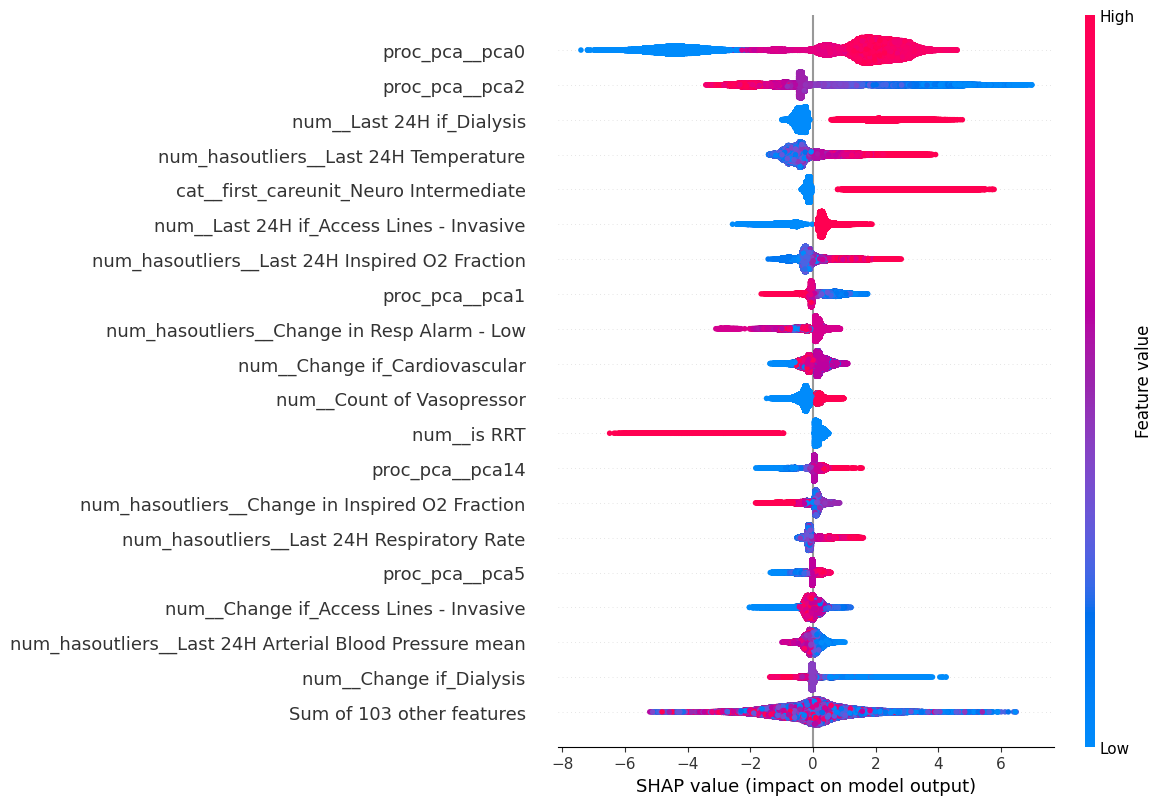

In [49]:
import shap
import pandas as pd

shap.initjs()

# Get the best pipeline
best_pipeline = grid_search.best_estimator_
model = best_pipeline.named_steps['regressor']
preprocessor = best_pipeline.named_steps['preprocessor']

X_test_transformed = preprocessor.transform(X_test)

# Get the feature names after transformation
try:
    feature_names = preprocessor.get_feature_names_out()
except Exception as e:
    print(f"Warning: Could not get feature names. Using default names. Error: {e}")
    feature_names = None

# Convert the transformed data back to a DataFrame with correct columns
X_test_transformed_df = pd.DataFrame(
    X_test_transformed, 
    columns=feature_names, 
    index=X_test.index
)

# Use shap.TreeExplainer for fast, exact results with LightGBM
explainer = shap.TreeExplainer(model)

# Calculate SHAP Values
shap_values = explainer(X_test_transformed_df)

# SHAP importance
plt.figure()
shap.plots.beeswarm(shap_values, max_display=20, show=False)
plt.savefig(explainability_folder +"shap2.png", bbox_inches='tight', dpi=300)

### Analyze common embeddings among all the PCAs

In [50]:
# Get the original embedding feature names
original_embedding_features = fitted_pca.feature_names_in_
loadings = fitted_pca.components_

pc_loadings_df = pd.DataFrame(
    loadings,
    columns=original_embedding_features,
    index=[f'pca{i}' for i in range(loadings.shape[0])]
)

# Find and count the most common top embeddings
top_pca_features_from_plot = ['pca2','pca0']

top_n = 10
# Store all top contributors in a list
all_top_contributors = []

for pc_name in top_pca_features_from_plot:
    if pc_name in pc_loadings_df.index:
        # Get the weights for this one component
        component_loadings = pc_loadings_df.loc[pc_name]
        # Get the top N features by absolute weight
        top_features = component_loadings.abs().sort_values(ascending=False).head(top_n)
        # Add names of the features to the list
        all_top_contributors.extend(top_features.index.tolist())
    else:
        print(f"Warning: {pc_name} not in PCA loadings. Skipping.")

# Count the occurrences of each embedding dimension
common_dimensions = Counter(all_top_contributors)

print(f"Most Common Top {top_n} Embeddings Across All Top PCs")
print(common_dimensions.most_common(10))

Most Common Top 10 Embeddings Across All Top PCs
[('proc_emb_70', 1), ('proc_emb_619', 1), ('proc_emb_674', 1), ('proc_emb_452', 1), ('proc_emb_124', 1), ('proc_emb_305', 1), ('proc_emb_661', 1), ('proc_emb_10', 1), ('proc_emb_541', 1), ('proc_emb_37', 1)]


### Embedding 131

In [61]:
analysis_df_1 = pd.DataFrame({
    'proc_emb': X_train['proc_emb_131'],
    'procedure_concat': df_train.loc[X_train.index, 'procedure_concat']
})

# Group by diagnosis text and calculate mean score + count
proc_stats = analysis_df_1.groupby('procedure_concat')['proc_emb'].agg(['mean', 'count'])

# Filter for diagnoses that appear at least 10 times
min_count = 10
common_proc_stats = proc_stats[proc_stats['count'] >= min_count].copy()

# Sort by the mean score
common_proc_stats = common_proc_stats.sort_values(by='mean')

# Get the top 15 lowest and top 15 highest procedures
top_15_proc_1 = common_proc_stats.tail(15).sort_values(by='mean', ascending=False)
top_15_proc_1

,mean,count
procedure_concat,,
"Interruption of the vena cava, Temporary tracheostomy, Other excision of joint, other specified sites, Other cervical fusion of the anterior column, anterior technique, Enteral infusion of concentrated nutritional substances, Closed [endoscopic] biopsy of bronchus, Percutaneous [endoscopic] gastrostomy [PEG], Fusion or refusion of 2-3 vertebrae, Closed [endoscopic] biopsy of bronchus, Fiber-optic bronchoscopy, Closed [endoscopic] biopsy of bronchus, Other intubation of respiratory tract, Other intubation of respiratory tract, Closed [endoscopic] biopsy of bronchus, Closed [endoscopic] biopsy of bronchus, Other intubation of respiratory tract, Other intubation of respiratory tract, Other intubation of respiratory tract, Closed [endoscopic] biopsy of bronchus, Other intubation of respiratory tract, Other intubation of respiratory tract, Closed [endoscopic] biopsy of bronchus, Fiber-optic bronchoscopy, Closed [endoscopic] biopsy of bronchus, Closed [endoscopic] biopsy of bronchus, Interruption of the vena cava, Temporary tracheostomy, Other excision of joint, other specified sites, Other cervical fusion of the anterior column, anterior technique, Enteral infusion of concentrated nutritional substances, Closed [endoscopic] biopsy of bronchus, Percutaneous [endoscopic] gastrostomy [PEG], Fusion or refusion of 2-3 vertebrae, Closed [endoscopic] biopsy of bronchus, Fiber-optic bronchoscopy, Closed [endoscopic] biopsy of bronchus, Other intubation of respiratory tract, Other intubation of respiratory tract, Closed [endoscopic] biopsy of bronchus, Closed [endoscopic] biopsy of bronchus, Other intubation of respiratory tract, Other intubation of respiratory tract, Other intubation of respiratory tract, Closed [endoscopic] biopsy of bronchus, Other intubation of respiratory tract, Other intubation of respiratory tract, Closed [endoscopic] biopsy of bronchus, Fiber-optic bronchoscopy, Closed [endoscopic] biopsy of bronchus, Closed [endoscopic] biopsy of bronchus",0.764430,84
"Inspection of Right Lung, Percutaneous Endoscopic Approach, Control Bleeding in Mediastinum, Open Approach, Drainage of Mediastinum, Open Approach, Insertion of Infusion Device into Superior Vena Cava, Percutaneous Approach, Inspection of Right Lung, Percutaneous Endoscopic Approach, Control Bleeding in Mediastinum, Open Approach, Drainage of Mediastinum, Open Approach, Insertion of Infusion Device into Superior Vena Cava, Percutaneous Approach",0.714277,28
"Inspection of Right Lung, Percutaneous Endoscopic Approach, Control Bleeding in Mediastinum, Open Approach, Drainage of Mediastinum, Open Approach, Inspection of Mediastinum, Open Approach, Repair Sternum, Open Approach, Inspection of Upper Intestinal Tract, Via Natural or Artificial Opening Endoscopic, Insertion of Infusion Device into Superior Vena Cava, Percutaneous Approach, Performance of Urinary Filtration, Continuous, Greater than 18 hours Per Day, Introduction of Nutritional Substance into Upper GI, Via Natural or Artificial Opening, Insertion of Monitoring Device into Upper Artery, Percutaneous Approach, Inspection of Right Lung, Percutaneous Endoscopic Approach, Control Bleeding in Mediastinum, Open Approach, Drainage of Mediastinum, Open Approach, Inspection of Mediastinum, Open Approach, Repair Sternum, Open Approach, Inspection of Upper Intestinal Tract, Via Natural or Artificial Opening Endoscopic, Insertion of Infusion Device into Superior Vena Cava, Percutaneous Approach, Performance of Urinary Filtration, Continuous, Greater than 18 hours Per Day, Introduction of Nutritional Substance into Upper GI, Via Natural or Artificial Opening, Insertion of Monitoring Device into Upper Artery, Percutaneous Approach",0.681625,56
"Inspection of Right Lung, Percutaneous Endoscopic Approach, Control Bleeding in Mediastinum, Open Approach, Drainage of Mediastinum, Open Approach, Insertion of Infusion Device into Superior Vena Cava, Percutaneous Approach, Performance of Urinary Fil

### Embedding 70

In [62]:
analysis_df_2 = pd.DataFrame({
    'proc_emb': X_train['proc_emb_70'],
    'procedure_concat': df_train.loc[X_train.index, 'procedure_concat']
})

# Group by diagnosis text and calculate mean score + count
proc_stats = analysis_df_1.groupby('procedure_concat')['proc_emb'].agg(['mean', 'count'])

# Filter for diagnoses that appear at least 10 times
min_count = 10
common_proc_stats = proc_stats[proc_stats['count'] >= min_count].copy()

# Sort by the mean score
common_proc_stats = common_proc_stats.sort_values(by='mean')

# Get the top 15 lowest and top 15 highest diagnoses
top_15_proc_2 = common_proc_stats.tail(15).sort_values(by='mean', ascending=False)
top_15_proc_2

,mean,count
procedure_concat,,
"Interruption of the vena cava, Temporary tracheostomy, Other excision of joint, other specified sites, Other cervical fusion of the anterior column, anterior technique, Enteral infusion of concentrated nutritional substances, Closed [endoscopic] biopsy of bronchus, Percutaneous [endoscopic] gastrostomy [PEG], Fusion or refusion of 2-3 vertebrae, Closed [endoscopic] biopsy of bronchus, Fiber-optic bronchoscopy, Closed [endoscopic] biopsy of bronchus, Other intubation of respiratory tract, Other intubation of respiratory tract, Closed [endoscopic] biopsy of bronchus, Closed [endoscopic] biopsy of bronchus, Other intubation of respiratory tract, Other intubation of respiratory tract, Other intubation of respiratory tract, Closed [endoscopic] biopsy of bronchus, Other intubation of respiratory tract, Other intubation of respiratory tract, Closed [endoscopic] biopsy of bronchus, Fiber-optic bronchoscopy, Closed [endoscopic] biopsy of bronchus, Closed [endoscopic] biopsy of bronchus, Interruption of the vena cava, Temporary tracheostomy, Other excision of joint, other specified sites, Other cervical fusion of the anterior column, anterior technique, Enteral infusion of concentrated nutritional substances, Closed [endoscopic] biopsy of bronchus, Percutaneous [endoscopic] gastrostomy [PEG], Fusion or refusion of 2-3 vertebrae, Closed [endoscopic] biopsy of bronchus, Fiber-optic bronchoscopy, Closed [endoscopic] biopsy of bronchus, Other intubation of respiratory tract, Other intubation of respiratory tract, Closed [endoscopic] biopsy of bronchus, Closed [endoscopic] biopsy of bronchus, Other intubation of respiratory tract, Other intubation of respiratory tract, Other intubation of respiratory tract, Closed [endoscopic] biopsy of bronchus, Other intubation of respiratory tract, Other intubation of respiratory tract, Closed [endoscopic] biopsy of bronchus, Fiber-optic bronchoscopy, Closed [endoscopic] biopsy of bronchus, Closed [endoscopic] biopsy of bronchus",0.764430,84
"Inspection of Right Lung, Percutaneous Endoscopic Approach, Control Bleeding in Mediastinum, Open Approach, Drainage of Mediastinum, Open Approach, Insertion of Infusion Device into Superior Vena Cava, Percutaneous Approach, Inspection of Right Lung, Percutaneous Endoscopic Approach, Control Bleeding in Mediastinum, Open Approach, Drainage of Mediastinum, Open Approach, Insertion of Infusion Device into Superior Vena Cava, Percutaneous Approach",0.714277,28
"Inspection of Right Lung, Percutaneous Endoscopic Approach, Control Bleeding in Mediastinum, Open Approach, Drainage of Mediastinum, Open Approach, Inspection of Mediastinum, Open Approach, Repair Sternum, Open Approach, Inspection of Upper Intestinal Tract, Via Natural or Artificial Opening Endoscopic, Insertion of Infusion Device into Superior Vena Cava, Percutaneous Approach, Performance of Urinary Filtration, Continuous, Greater than 18 hours Per Day, Introduction of Nutritional Substance into Upper GI, Via Natural or Artificial Opening, Insertion of Monitoring Device into Upper Artery, Percutaneous Approach, Inspection of Right Lung, Percutaneous Endoscopic Approach, Control Bleeding in Mediastinum, Open Approach, Drainage of Mediastinum, Open Approach, Inspection of Mediastinum, Open Approach, Repair Sternum, Open Approach, Inspection of Upper Intestinal Tract, Via Natural or Artificial Opening Endoscopic, Insertion of Infusion Device into Superior Vena Cava, Percutaneous Approach, Performance of Urinary Filtration, Continuous, Greater than 18 hours Per Day, Introduction of Nutritional Substance into Upper GI, Via Natural or Artificial Opening, Insertion of Monitoring Device into Upper Artery, Percutaneous Approach",0.681625,56
"Inspection of Right Lung, Percutaneous Endoscopic Approach, Control Bleeding in Mediastinum, Open Approach, Drainage of Mediastinum, Open Approach, Insertion of Infusion Device into Superior Vena Cava, Percutaneous Approach, Performance of Urinary Fil

### Word Cloud for high and low scores

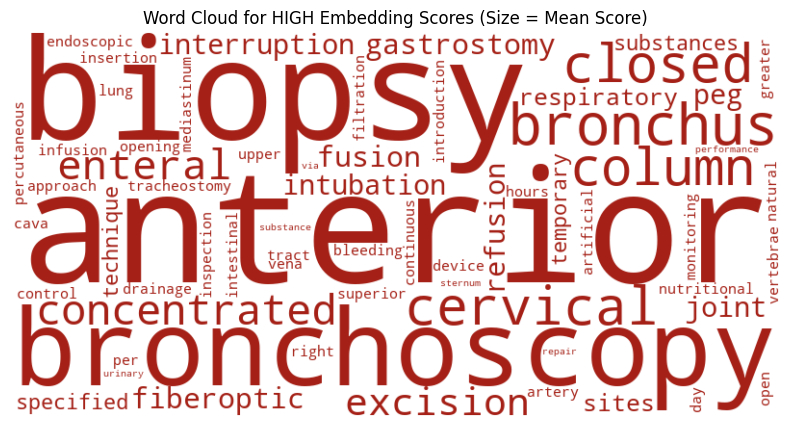

In [63]:
# Multiply proc_2 with -1 since it's inversely related to importance
top_15_proc_2['mean'] = -1*top_15_proc_2['mean']

# Union the 2 dataframes
analysis_df = pd.concat([top_15_proc_1,top_15_proc_2]).reset_index()

# Drop any rows where diagnosis text is NaN
analysis_df = analysis_df.dropna(subset=['procedure_concat'])

# Get the quantile thresholds
top_quantile = analysis_df['mean'].quantile(0.9)
bottom_quantile = analysis_df['mean'].quantile(0.1)

# Get the texts for the top and bottom scores
top_df = analysis_df[analysis_df['mean'] >= top_quantile]
bottom_df = analysis_df[analysis_df['mean'] <= bottom_quantile]

# Add common medical stopwords, and updated based on what was seen in the chart
stopwords = set(STOPWORDS)
stopwords.update([
    "previously","lesser","products","computer","length","indirect","bandage","component","advancement","route"])


# Takes a dataframe, tokenizes the diagnosis_text and returns a dict of {word: mean_score}
def create_word_score_dict(df, score_column='mean'):
    df = df.assign(procedure_concat=df['procedure_concat'].astype(str).str.lower())
    
    # Split each diagnosis into a list of words
    df = df.assign(procedure_concat=df['procedure_concat'].str.split())
    
    # Explode the dataframe so each word has its own row
    exploded_df = df.explode('procedure_concat')
    
    # Remove punctuation and non-alphabetical characters
    exploded_df['word'] = exploded_df['procedure_concat'].str.replace(r'[^a-z]', '', regex=True)
    
    # Filter out stopwords and short/empty words
    exploded_df = exploded_df[~exploded_df['word'].isin(stopwords)]
    # Keep words longer than 2 chars
    exploded_df = exploded_df[exploded_df['word'].str.len() > 2]
    
    # Group by the clean word and get the mean embedding score
    word_scores = exploded_df.groupby('word')[score_column].mean()
    
    return word_scores.to_dict()

# Create the dictionaries
top_word_scores = create_word_score_dict(top_df)

# Generate Word Cloud
wc_top = WordCloud(
    background_color='white', 
    max_words=100, 
    width=800, 
    height=400,
    colormap='Reds',
    color_func=lambda *args, **kwargs: '#a52117'
).generate_from_frequencies(top_word_scores)

plt.figure(figsize=(10, 5))
plt.imshow(wc_top, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud for HIGH Embedding Scores (Size = Mean Score)')
plt.savefig(explainability_folder +"wc1.png", dpi=300)
plt.show()

### Look at cluster of the keywords..

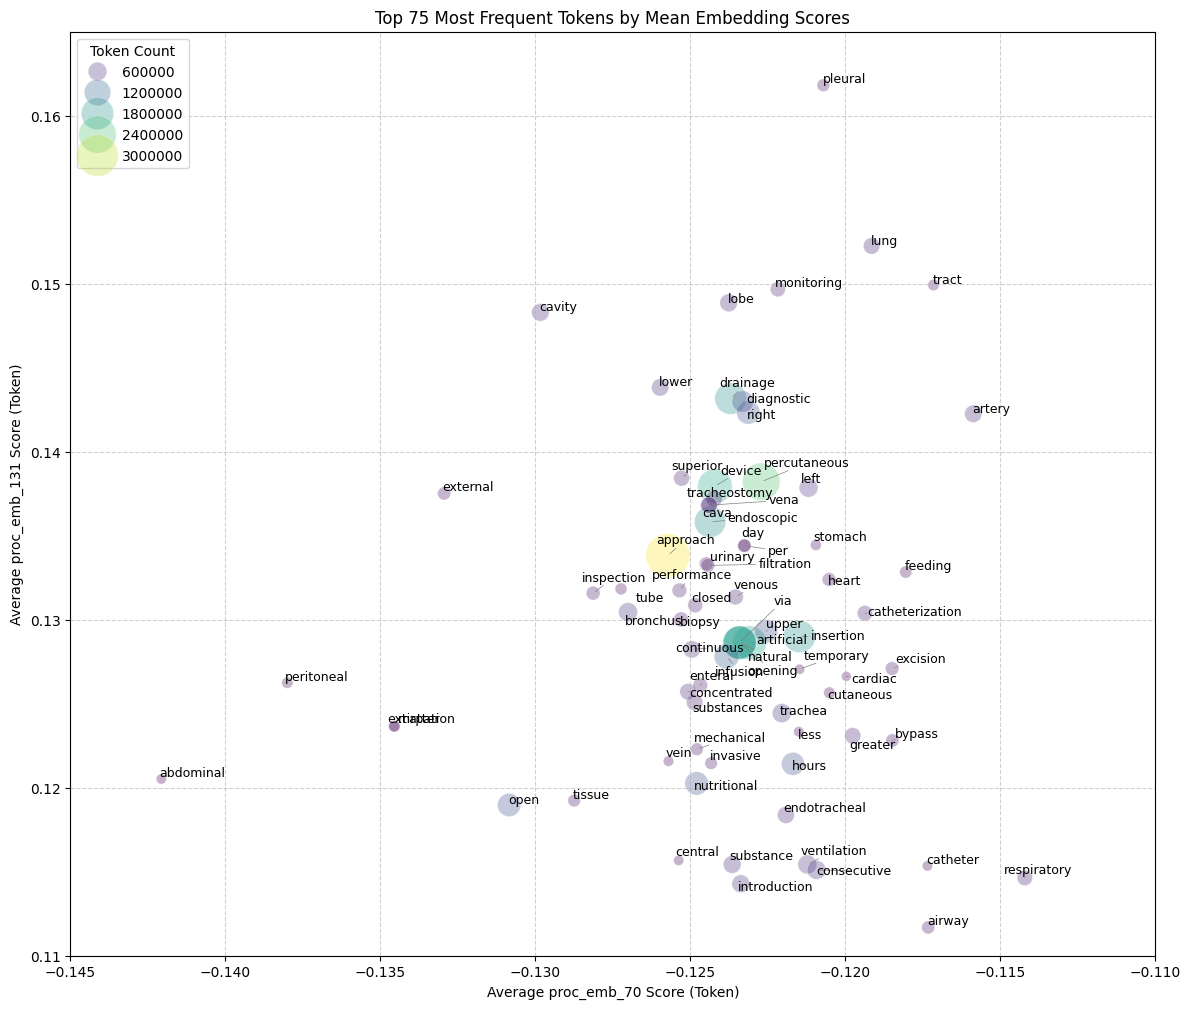

In [64]:
# Combine the 2 dataframes
analysis_df = pd.DataFrame({
    'proc_emb_70': X_train['proc_emb_70'],
    'proc_emb_131': X_train['proc_emb_131'],
    'procedure_concat': df_train.loc[X_train.index, 'procedure_concat']
})

# Drop any rows where diagnosis text is NaN
analysis_df = analysis_df.dropna(subset=['procedure_concat'])

# Define stopwords
stopwords = set(STOPWORDS)
stopwords.update([
    "previously","lesser","products","computer","length","using","elsewhere","classified"])

# Make sure text is string and lowercase
analysis_df['procedure_concat'] = analysis_df['procedure_concat'].astype(str).str.lower()

# Split each diagnosis into a list of words
analysis_df['words'] = analysis_df['procedure_concat'].str.split()

# Explode the DataFrame so each word has its own row, associated with its original scores
token_df = analysis_df.explode('words')

# Remove punctuation and non-alpha characters
token_df['token'] = token_df['words'].str.replace(r'[^a-z]', '', regex=True)

# Filter out stopwords and short/empty words
token_df = token_df[~token_df['token'].isin(stopwords)]
# Keep words longer than 2 chars
token_df = token_df[token_df['token'].str.len() > 2] 

# Group by the clean token and get the mean scores and count
token_stats = token_df.groupby('token').agg(
    mean_1=('proc_emb_70', 'mean'),
    mean_2=('proc_emb_131', 'mean'),
    count=('proc_emb_70', 'count')
)

# Filter for Top 100 Tokens
top_n_tokens = 75
top_100_tokens_stats = token_stats.sort_values(by='count', ascending=False).head(top_n_tokens).copy()

# Plot the Scatter Plot
plt.figure(figsize=(14, 12))
sns.scatterplot(
    data=top_100_tokens_stats,
    x='mean_1',
    y='mean_2',
    size='count',
    hue='count',
    palette='viridis',
    sizes=(50, 1000),
    alpha=0.3
)

texts = []

# Create a list of all text objects
for token, row in top_100_tokens_stats.iterrows():
    texts.append(
        plt.text(row['mean_1'], row['mean_2'], token, fontsize=9)
    )

# Run the adjust_text function to move labels automatically
adjust_text(texts, arrowprops=dict(arrowstyle='-', color='gray', lw=0.5))

# Adjust to get the right zoom
plt.xlim(-0.145, -0.11) 
plt.ylim(0.11, 0.165)
# Plot
plt.title(f'Top {top_n_tokens} Most Frequent Tokens by Mean Embedding Scores')
plt.xlabel('Average proc_emb_70 Score (Token)')
plt.ylabel('Average proc_emb_131 Score (Token)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.axhline(0, color='black', linewidth=0.5)
plt.axvline(0, color='black', linewidth=0.5)
plt.legend(title='Token Count', loc='upper left')
plt.savefig(explainability_folder +"sp.png", dpi=300)
plt.show()

In [65]:
X_test

,proc_emb_0,proc_emb_1,proc_emb_2,proc_emb_3,proc_emb_4,proc_emb_5,proc_emb_6,proc_emb_7,proc_emb_8,proc_emb_9,...,Last 24H Low risk (25-50) interventions,Change if_Access Lines - Invasive,Change if_Cardiovascular,Change if_Dialysis,Change if_IABP,Change if_Impella,Change High risk (>51) interventions,Change Low risk (25-50) interventions,Latest Vasopressor,is RRT
0,-0.042766,-0.071430,-0.294942,0.343399,0.250838,0.119699,0.058113,0.234308,0.434399,-0.121274,...,0.0,0.409091,-0.500000,0.272727,0.0,0.0,-0.454545,0.0,1,0
1,-0.023358,-0.117958,-0.326919,0.309959,0.250773,0.095861,0.076412,0.241103,0.340574,-0.116579,...,0.0,0.409091,-0.500000,0.272727,0.0,0.0,-0.454545,0.0,1,0
2,-0.019540,-0.074451,-0.300566,0.326193,0.213598,0.116864,0.122032,0.157824,0.299243,-0.127187,...,0.0,0.409091,-0.500000,0.272727,0.0,0.0,-0.454545,0.0,1,0
3,0.032189,-0.004743,-0.027144,0.307868,0.021235,-0.156854,-0.373556,0.174170,0.477350,-0.114937,...,0.0,0.391304,0.478261,0.260870,0.0,0.0,-0.434783,0.0,1,0
4,-0.019540,-0.074451,-0.300566,0.326193,0.213598,0.116864,0.122032,0.157824,0.299243,-0.127187,...,0.0,0.428571,0.476190,0.285714,0.0,0.0,0.523810,0.0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
242255,0.224822,-0.243634,-0.037915,0.126386,-0.160398,0.251306,0.203163,-0.016926,0.241982,-0.079763,...,0.0,0.000000,0.000000,0.000000,0.0,0.0,-0.250000,0.0,0,0
242256,0.224822,-0.243634,-0.037915,0.126386,-0.160398,0.251306,0.203163,-0.016926,0.241982,-0.079763,...,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.666667,0.0,0,0
242257,0.224822,-0.243634,-0.037915,0.126386,-0.160398,0.251306,0.203163,-0.016926,0.241982,-0.079763,...,0.0,0.000000,-0.857143,0.000000,0.0,0.0,-0.285714,0.0,0,0
242258,0.224822,-0.243634,-0.037915,0.126386,-0.160398,0.251306,0.203163,-0.016926,0.241982,-0.079763,...,0.0,0.000000,0.000000,0.000000,0.0,0.0,-0.333333,0.0,0,0


In [66]:
# Generate results for Ziyi to perform hybrid model
results_df = pd.DataFrame({
    'subject_id': test_set['subject_id'].values,
    'hadm_id': test_set['hadm_id'].values,
    'stay_id': test_set['stay_id'].values,
    'assigned_intime': test_set['assigned_intime'].values,
    'assigned_outtime': test_set['assigned_outtime'].values,
    'chartdate': test_set['chartdate'].values,
    'actual_los': y_test.values,
    'predicted_los': y_pred  # y_pred is already a numpy array
})

# Calculate the error
results_df['abs_error'] = (results_df['actual_los'] - results_df['predicted_los']).abs()
results_df

,subject_id,hadm_id,stay_id,assigned_intime,assigned_outtime,chartdate,actual_los,predicted_los,abs_error
0,17057610,26086792,30045625,2020-05-17 22:24:28,2020-06-16 18:16:36,2200-05-28,19,15.061204,3.938796e+00
1,17057610,26086792,30045625,2020-05-17 22:24:28,2020-06-16 18:16:36,2200-05-28,19,18.491903,5.080974e-01
2,17057610,26086792,30045625,2020-05-17 22:24:28,2020-06-16 18:16:36,2200-05-28,19,18.563823,4.361769e-01
3,17057610,26086792,30045625,2020-05-17 22:24:28,2020-06-16 18:16:36,2200-05-29,18,13.421564,4.578436e+00
4,17057610,26086792,30045625,2020-05-17 22:24:28,2020-06-16 18:16:36,2200-05-28,19,18.013564,9.864362e-01
...,...,...,...,...,...,...,...,...,...
242255,17598702,20473158,37693858,2025-06-23 05:27:15,2025-06-27 15:00:40,2144-06-25,2,1.000000,1.000000e+00
242256,17598702,20473158,37693858,2025-06-23 05:27:15,2025-06-27 15:00:40,2144-06-26,1,1.000000,1.265654e-14
242257,17598702,20473158,37693858,2025-06-23 05:27:15,2025-06-27 15:00:40,2144-06-27,1,1.000000,1.265654e-14
242258,17598702,20473158,37693858,2025-06-23 05:27:15,2025-06-27 15:00:40,2144-06-25,2,1.000000,1.000000e+00


In [67]:
results_df.to_csv(output_folder+ 'pivot/results.csv', index=False)